# IT25102687 — Feature scaling
Amaranayake D.R. | 2026-Y2-S1-KU-28

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# Mount Google Drive
try:
    from google.colab import drive
    drive.mount('/content/drive')
    ROOT = Path('/content/drive/MyDrive')
except ImportError:
    ROOT = Path.cwd()
    if ROOT.name == 'notebooks':
        ROOT = ROOT.parent

# Define output directories
FIG = ROOT / 'results/eda_visualizations'
OUT = ROOT / 'results/outputs'
FIG.mkdir(parents=True, exist_ok=True)
OUT.mkdir(parents=True, exist_ok=True)

# Define the NSL-KDD column names directly to avoid requiring column_names.csv
columns = [
    'duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes',
    'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in',
    'num_compromised', 'root_shell', 'su_attempted', 'num_root', 'num_file_creations',
    'num_shells', 'num_access_files', 'num_outbound_cmds', 'is_host_login',
    'is_guest_login', 'count', 'srv_count', 'serror_rate', 'srv_serror_rate',
    'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate',
    'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count',
    'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate',
    'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate',
    'dst_host_rerror_rate', 'dst_host_srv_rerror_rate', 'label', 'difficulty_level'
]

# Set correct file paths directly from My Drive
train_file = ROOT / 'KDDTrain+.txt'
test_file = ROOT / 'KDDTest+.txt'

# Load datasets
train = pd.read_csv(train_file, names=columns)

try:
    test = pd.read_csv(test_file, names=columns)
except FileNotFoundError:
    print("Warning: KDDTest+.txt not found in Google Drive. Initializing an empty DataFrame for testing.")
    test = pd.DataFrame(columns=columns)

print('Train:', train.shape, 'Test:', test.shape)
display(train.head())

Mounted at /content/drive
Train: (125973, 43) Test: (22544, 43)


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,difficulty_level
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


In [2]:
## 2. Fit on training; transform test

scaler = StandardScaler()
scaled_train = scaler.fit_transform(train[['duration', 'count']])
scaled_test = scaler.transform(test[['duration', 'count']])
display(pd.DataFrame(scaled_train, columns=['duration', 'count']).head())
print('Training means:', scaled_train.mean(axis=0).round(6))
print('Training standard deviations:', scaled_train.std(axis=0).round(6))


,duration,count
0,-0.110249,-0.717045
1,-0.110249,-0.620982
2,-0.110249,0.339648
3,-0.110249,-0.690846
4,-0.110249,-0.472521


Training means: [ 0. -0.]
Training standard deviations: [1. 1.]


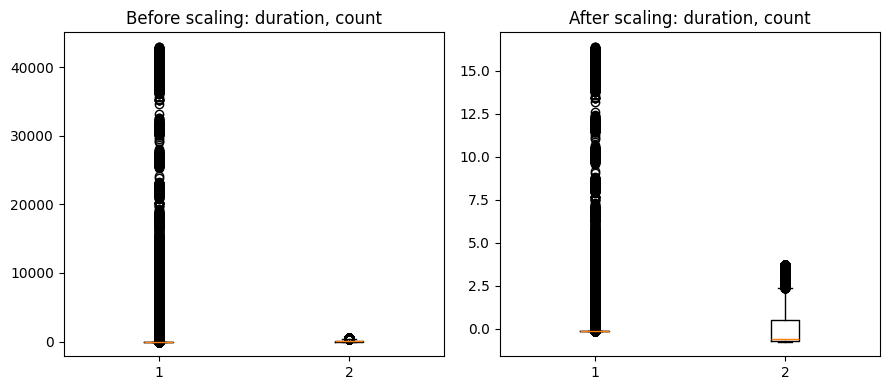

In [3]:
## 3. Compare numerical units

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
axes[0].boxplot(train[['duration', 'count']].to_numpy())
axes[0].set_title('Before scaling: duration, count')
axes[1].boxplot(scaled_train)
axes[1].set_title('After scaling: duration, count')
plt.tight_layout()
plt.savefig(FIG / '04_scaling.png', dpi=140, bbox_inches='tight')
plt.show()
